In [1]:
import pandas as pd
import shap
shap.initjs()

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('../data/cab_rides_features.csv')
df.head(10)

,distance,cab_type,destination,source,price,surge_multiplier,name,ride_time,temp,clouds,...,is_weekend,time_of_day,base_price_per_mile,effective_surge,ride_hour_bucket,rides_in_hour_at_source,demand_density,uber_lyft_price_ratio,is_raining,bad_weather_score
0,3.03,Lyft,Theatre District,Boston University,34.0,1.00,Lux Black XL,2018-11-26 03:40:46.318,41.07,0.86,...,False,late_night,10.833333,1.035796,2018-11-26 03:00:00,9,low,NaN,False,0.311602
1,1.30,Uber,Theatre District,South Station,18.5,1.00,Black,2018-11-26 03:40:46.319,40.86,0.87,...,False,late_night,11.538462,1.233333,2018-11-26 03:00:00,11,low,NaN,False,0.319336
2,2.43,Lyft,Beacon Hill,Northeastern University,10.5,1.00,Lyft,2018-11-26 03:40:46.320,40.81,0.89,...,False,late_night,3.673469,1.176269,2018-11-26 03:00:00,4,low,NaN,False,0.321602
3,2.71,Uber,Fenway,Theatre District,32.0,1.00,UberXL,2018-11-26 03:40:46.320,40.80,0.87,...,False,late_night,5.639098,2.093973,2018-11-26 03:00:00,13,low,2.755102,False,0.318420
4,2.71,Uber,Fenway,Theatre District,19.5,1.00,UberX,2018-11-26 03:40:46.320,40.80,0.87,...,False,late_night,3.571429,2.014760,2018-11-26 03:00:00,13,low,2.755102,False,0.318420
5,2.19,Uber,North End,Beacon Hill,17.5,1.00,Black,2018-11-26 03:40:46.358,41.02,0.87,...,False,late_night,8.371041,0.954585,2018-11-26 03:00:00,7,low,NaN,False,0.317503
6,3.05,Uber,Fenway,North Station,10.5,1.00,WAV,2018-11-26 03:40:46.358,40.94,0.89,...,False,late_night,3.114754,1.105263,2018-11-26 03:00:00,5,low,NaN,False,0.322886
7,2.19,Uber,North End,Beacon Hill,8.0,1.00,UberX,2018-11-26 03:40:46.358,41.02,0.87,...,False,late_night,3.881279,0.941176,2018-11-26 03:00:00,7,low,NaN,False,0.317503
8,2.19,Uber,North End,Beacon Hill,13.0,1.00,UberXL,2018-11-26 03:40:46.358,41.02,0.87,...,False,late_night,6.164384,0.962963,2018-11-26 03:00:00,7,low,NaN,False,0.317503
9,4.46,Lyft,Financial District,Boston University,47.5,1.75,Lux,2018-11-26 03:40:46.359,41.07,0.86,...,False,late_night,4.880694,2.182113,2018-11-26 03:00:00,9,low,NaN,False,0.311602


In [4]:
import sys
sys.path.append("..")
from helper_functions.prep_data_function import prepare_train_test
X_train, X_test, y_train, y_test = prepare_train_test("../data/cab_rides_features.csv")
X_train

,cab_type,name,source,destination,time_of_day,demand_density,distance,rides_in_hour_at_source,bad_weather_score,is_raining,is_weekend,ride_hour,uber_lyft_price_ratio
0,Lyft,Lux Black XL,Boston University,Theatre District,late_night,low,3.03,9,0.311602,False,False,3,NaN
1,Uber,Black,South Station,Theatre District,late_night,low,1.30,11,0.319336,False,False,3,NaN
2,Lyft,Lyft,Northeastern University,Beacon Hill,late_night,low,2.43,4,0.321602,False,False,3,NaN
3,Uber,UberXL,Theatre District,Fenway,late_night,low,2.71,13,0.318420,False,False,3,2.755102
4,Uber,UberX,Theatre District,Fenway,late_night,low,2.71,13,0.318420,False,False,3,2.755102
...,...,...,...,...,...,...,...,...,...,...,...,...,...
510380,Lyft,Lux,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.802513
510379,Lyft,Lyft XL,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.802513
510376,Lyft,Lux Black,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.802513
510377,Lyft,Lyft,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.802513


In [5]:
import xgboost as xgb
model = xgb.XGBRegressor(enable_categorical=True,tree_method="hist",random_state=42)
model.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [6]:
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_true=y_test,y_pred=y_pred)

0.561470960136909

In [7]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

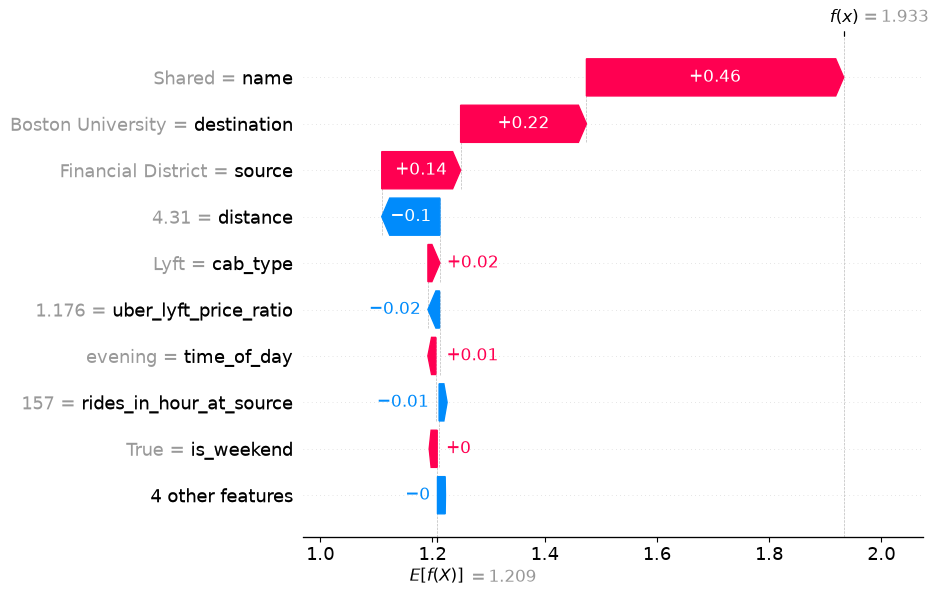

In [8]:
shap.plots.waterfall(shap_values[0])

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_true=y_test,y_pred=y_pred)**0.5
mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
rmse, mae

(0.1994423985578342, 0.11885380783853638)

In [10]:
y_train_pred = model.predict(X_train)
r2_score(y_true=y_train,y_pred=y_train_pred)

0.6129353222309926

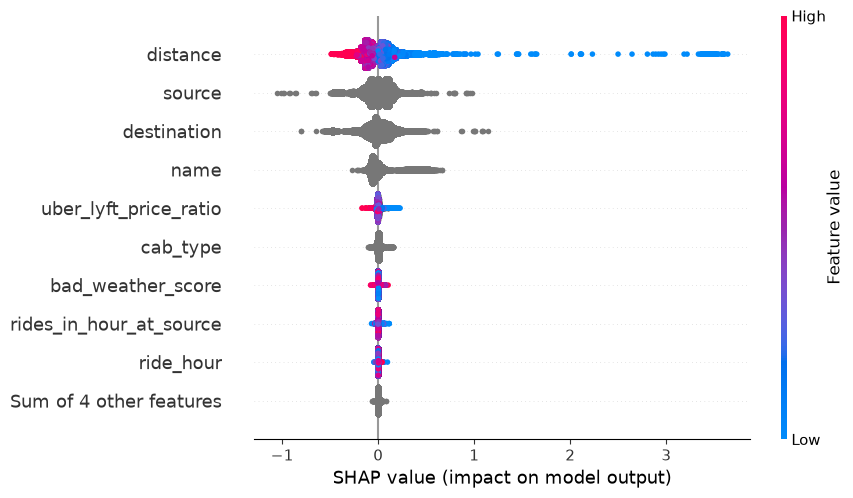

In [11]:
shap.plots.beeswarm(shap_values)